# CBG Panel C - Seizure Blocking Dynamics

**Objective**: Compare untreated seizure-driven cFos progression versus treatment-triggered suppression using a compact time-course model.

## Simulation Story
1. **Untreated arm**: cFos starts near 0, rises over five windows, and plateaus.
2. **Treated arm**: cFos initially rises similarly, then interstitial drug concentration builds and suppresses cFos.
3. The treated trajectory should show a brief early blip followed by sustained suppression.

## Five windows (minutes)
- W1: 0-10
- W2: 10-20
- W3: 20-30
- W4: 30-45
- W5: 45-60

In [1]:
# Cell 1: imports, paths, and default parameters
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage
from scipy.integrate import solve_ivp

OUT_DIR = Path('CBG_panel_C_outputs')
OUT_DIR.mkdir(exist_ok=True)

# Shared fixed values kept consistent with repository conventions where relevant.
D_tissue = 3e-4
P_intact = 1e-4
P_open = 5e-3
k_e = 0.05

# Time grid and five windows
T_END = 60.0
T_EVAL = np.linspace(0.0, T_END, 1201)
WINDOWS = [(0, 10), (10, 20), (20, 30), (30, 45), (45, 60)]
WINDOW_LABELS = ['W1', 'W2', 'W3', 'W4', 'W5']

# Dynamics parameters (calibrated for 'blip then sustained suppression').
PARAMS = {
    'S_on': 8.0,
    'S_rise_tau': 5.0,
    'S_decay_tau': 18.0,
    'S_drive_max': 1.0,
    'S_pulse_off': 42.0,

    'A_max': 45.0,
    'k_induce': 0.42,
    'k_decay': 0.035,

    'treat_on': 16.0,
    'C_input': 1.0,
    'k_in': 0.32,
    'k_clear': 0.07,

    'k_sup': 0.1,
    'EC50': 0.22,
    'hill_n': 2.4,

    'S_supp_coupling': 0.0,
}

print('Notebook C initialized.')
print(f'Output directory: {OUT_DIR.resolve()}')

Notebook C initialized.
Output directory: /Users/k2477067/Code/BBB_modelling/CBG_panel_C_outputs


In [2]:
# Cell 2: model functions
def seizure_drive(t, p):
    if t < p['S_on']:
        return 0.0
    if t <= p['S_pulse_off']:
        return p['S_drive_max'] * (1.0 - np.exp(-(t - p['S_on']) / p['S_rise_tau']))
    s_at_off = p['S_drive_max'] * (1.0 - np.exp(-(p['S_pulse_off'] - p['S_on']) / p['S_rise_tau']))
    return s_at_off * np.exp(-(t - p['S_pulse_off']) / p['S_decay_tau'])


def hill_suppression(C, p):
    n = p['hill_n']
    ec = p['EC50']
    return (C**n) / (ec**n + C**n + 1e-12)


def make_rhs(params, treated=False, blip_off=None):
    def rhs(t, y):
        A, S, C = y
        p = params

        S_target = seizure_drive(t, p)
        dS = (S_target - S) / max(p['S_rise_tau'], 1e-6)

        C_target = 0.0
        if treated and t >= p['treat_on']:
            C_target = p['C_input']
            if blip_off is not None and t > blip_off:
                C_target = 0.0

        dC = p['k_in'] * max(C_target - C, 0.0) - p['k_clear'] * C

        sup = hill_suppression(max(C, 0.0), p) if treated else 0.0
        dA = p['k_induce'] * S * (1.0 - A / max(p['A_max'], 1e-6)) - p['k_decay'] * A - p['k_sup'] * sup * A

        if treated:
            dS = dS - p['S_supp_coupling'] * sup * S

        return [dA, dS, dC]

    return rhs


def run_scenario(params, treated=False, blip_duration=None):
    y0 = [0.0, 0.0, 0.0]
    blip_off = None
    if treated and blip_duration is not None:
        blip_off = params['treat_on'] + blip_duration

    sol = solve_ivp(
        make_rhs(params, treated=treated, blip_off=blip_off),
        t_span=(0.0, T_END),
        y0=y0,
        t_eval=T_EVAL,
        method='Radau',
        max_step=0.25,
        rtol=1e-6,
        atol=1e-8,
    )
    if not sol.success:
        raise RuntimeError(f'Solver failed: {sol.message}')
    return sol

In [3]:
# Cell 3: run primary scenarios
sol_untreated = run_scenario(PARAMS, treated=False)
sol_treated = run_scenario(PARAMS, treated=True)

# Optional diagnostic arm: short treatment blip then rebound risk.
INCLUDE_BLIP_ARM = True
BLIP_DURATION_MIN = 8.0
sol_blip = run_scenario(PARAMS, treated=True, blip_duration=BLIP_DURATION_MIN) if INCLUDE_BLIP_ARM else None

A_u, S_u, C_u = sol_untreated.y
A_t, S_t, C_t = sol_treated.y
if sol_blip is not None:
    A_b, S_b, C_b = sol_blip.y

# Avoid misleading early efficacy when untreated cFos is still near zero.
EFFICACY_MIN_REF = 0.15
efficacy = np.full_like(A_u, np.nan, dtype=float)
valid_ref = A_u >= EFFICACY_MIN_REF
efficacy[valid_ref] = 1.0 - (A_t[valid_ref] / np.maximum(A_u[valid_ref], 1e-6))
efficacy = np.clip(efficacy, -1.0, 1.0)

print('Scenarios solved: untreated, treated' + (', blip' if sol_blip is not None else ''))
print(f'Max untreated cFos: {np.max(A_u):.2f}')
print(f'Max treated cFos  : {np.max(A_t):.2f}')
print(f'Treated final cFos: {A_t[-1]:.2f}')
print(f'Efficacy valid after untreated cFos >= {EFFICACY_MIN_REF:.2f}')

Scenarios solved: untreated, treated, blip
Max untreated cFos: 6.97
Max treated cFos  : 2.85
Treated final cFos: 2.10
Efficacy valid after untreated cFos >= 0.15


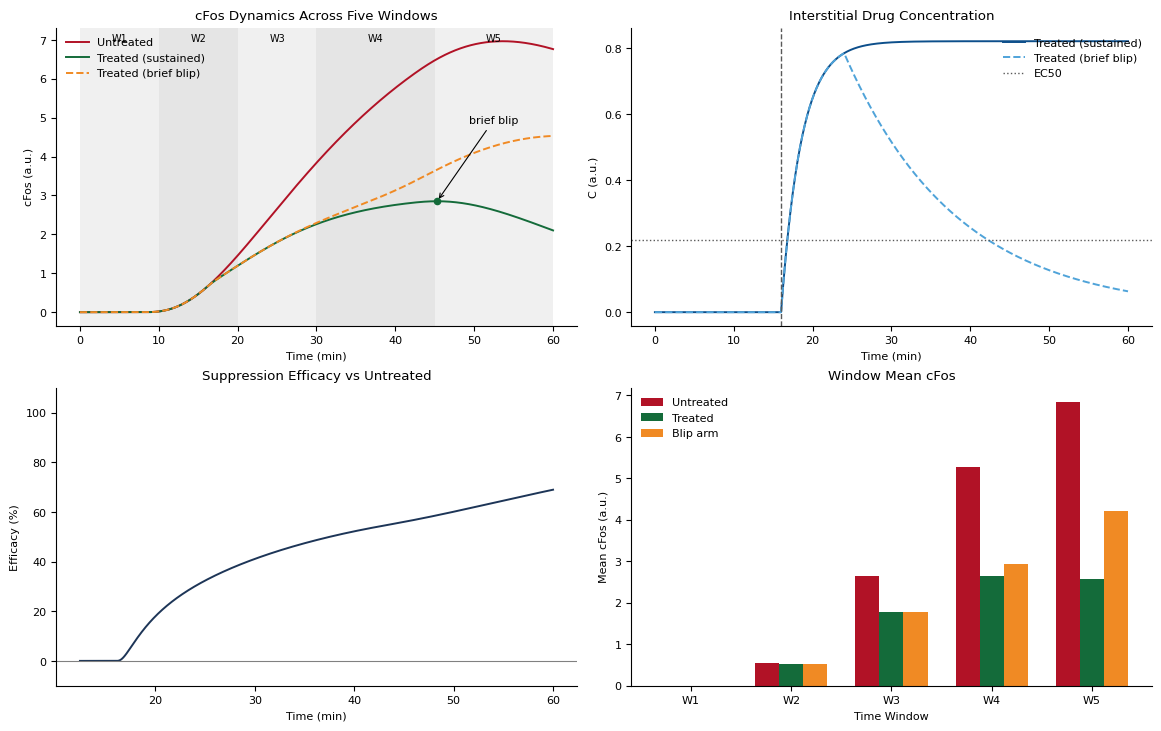

In [4]:
# Cell 4: plotting (trajectories + window summaries)
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 8,
    'axes.linewidth': 0.8,
    'lines.linewidth': 1.4,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

fig, axes = plt.subplots(2, 2, figsize=(11.5, 7.2), constrained_layout=True)
ax1, ax2, ax3, ax4 = axes.ravel()

# Plot 1: cFos trajectories with windows
for i, (w0, w1) in enumerate(WINDOWS):
    ax1.axvspan(w0, w1, color='0.92' if i % 2 == 0 else '0.86', alpha=0.7, lw=0)
    ax1.text((w0 + w1) / 2, 0.98, WINDOW_LABELS[i], transform=ax1.get_xaxis_transform(),
             ha='center', va='top', fontsize=7)

ax1.plot(T_EVAL, A_u, color='#b11226', label='Untreated')
ax1.plot(T_EVAL, A_t, color='#146b3a', label='Treated (sustained)')
if sol_blip is not None:
    ax1.plot(T_EVAL, A_b, color='#f08a24', linestyle='--', label='Treated (brief blip)')

peak_idx = int(np.argmax(A_t))
ax1.scatter([T_EVAL[peak_idx]], [A_t[peak_idx]], color='#146b3a', s=20, zorder=4)
ax1.annotate('brief blip', (T_EVAL[peak_idx], A_t[peak_idx]),
             xytext=(T_EVAL[peak_idx] + 4, A_t[peak_idx] + 2.0),
             arrowprops={'arrowstyle': '->', 'lw': 0.8}, fontsize=8)

ax1.set_title('cFos Dynamics Across Five Windows')
ax1.set_xlabel('Time (min)')
ax1.set_ylabel('cFos (a.u.)')
ax1.legend(frameon=False, loc='upper left')

# Plot 2: interstitial drug
ax2.plot(T_EVAL, C_t, color='#0d4f8b', label='Treated (sustained)')
if sol_blip is not None:
    ax2.plot(T_EVAL, C_b, color='#4fa3d9', linestyle='--', label='Treated (brief blip)')
ax2.axhline(PARAMS['EC50'], color='0.35', linestyle=':', linewidth=1.0, label='EC50')
ax2.axvline(PARAMS['treat_on'], color='0.35', linestyle='--', linewidth=1.0)
ax2.set_title('Interstitial Drug Concentration')
ax2.set_xlabel('Time (min)')
ax2.set_ylabel('C (a.u.)')
ax2.legend(frameon=False, loc='upper right')

# Plot 3: suppression efficacy
ax3.plot(T_EVAL, 100 * efficacy, color='#1d3557')
ax3.axhline(0, color='0.5', linewidth=0.8)
ax3.set_ylim(-10, 110)
ax3.set_title('Suppression Efficacy vs Untreated')
ax3.set_xlabel('Time (min)')
ax3.set_ylabel('Efficacy (%)')

# Plot 4: window-mean cFos
u_means, t_means, b_means = [], [], []
for w0, w1 in WINDOWS:
    m = (T_EVAL >= w0) & (T_EVAL < w1)
    u_means.append(float(np.mean(A_u[m])))
    t_means.append(float(np.mean(A_t[m])))
    if sol_blip is not None:
        b_means.append(float(np.mean(A_b[m])))

xpos = np.arange(len(WINDOWS))
bar_w = 0.24 if sol_blip is not None else 0.34
ax4.bar(xpos - bar_w, u_means, width=bar_w, color='#b11226', label='Untreated')
ax4.bar(xpos, t_means, width=bar_w, color='#146b3a', label='Treated')
if sol_blip is not None:
    ax4.bar(xpos + bar_w, b_means, width=bar_w, color='#f08a24', label='Blip arm')

ax4.set_xticks(xpos)
ax4.set_xticklabels(WINDOW_LABELS)
ax4.set_title('Window Mean cFos')
ax4.set_xlabel('Time Window')
ax4.set_ylabel('Mean cFos (a.u.)')
ax4.legend(frameon=False)

fig.savefig(OUT_DIR / 'CBG_panel_C_debug.svg', bbox_inches='tight', pad_inches=0.02)
plt.show()

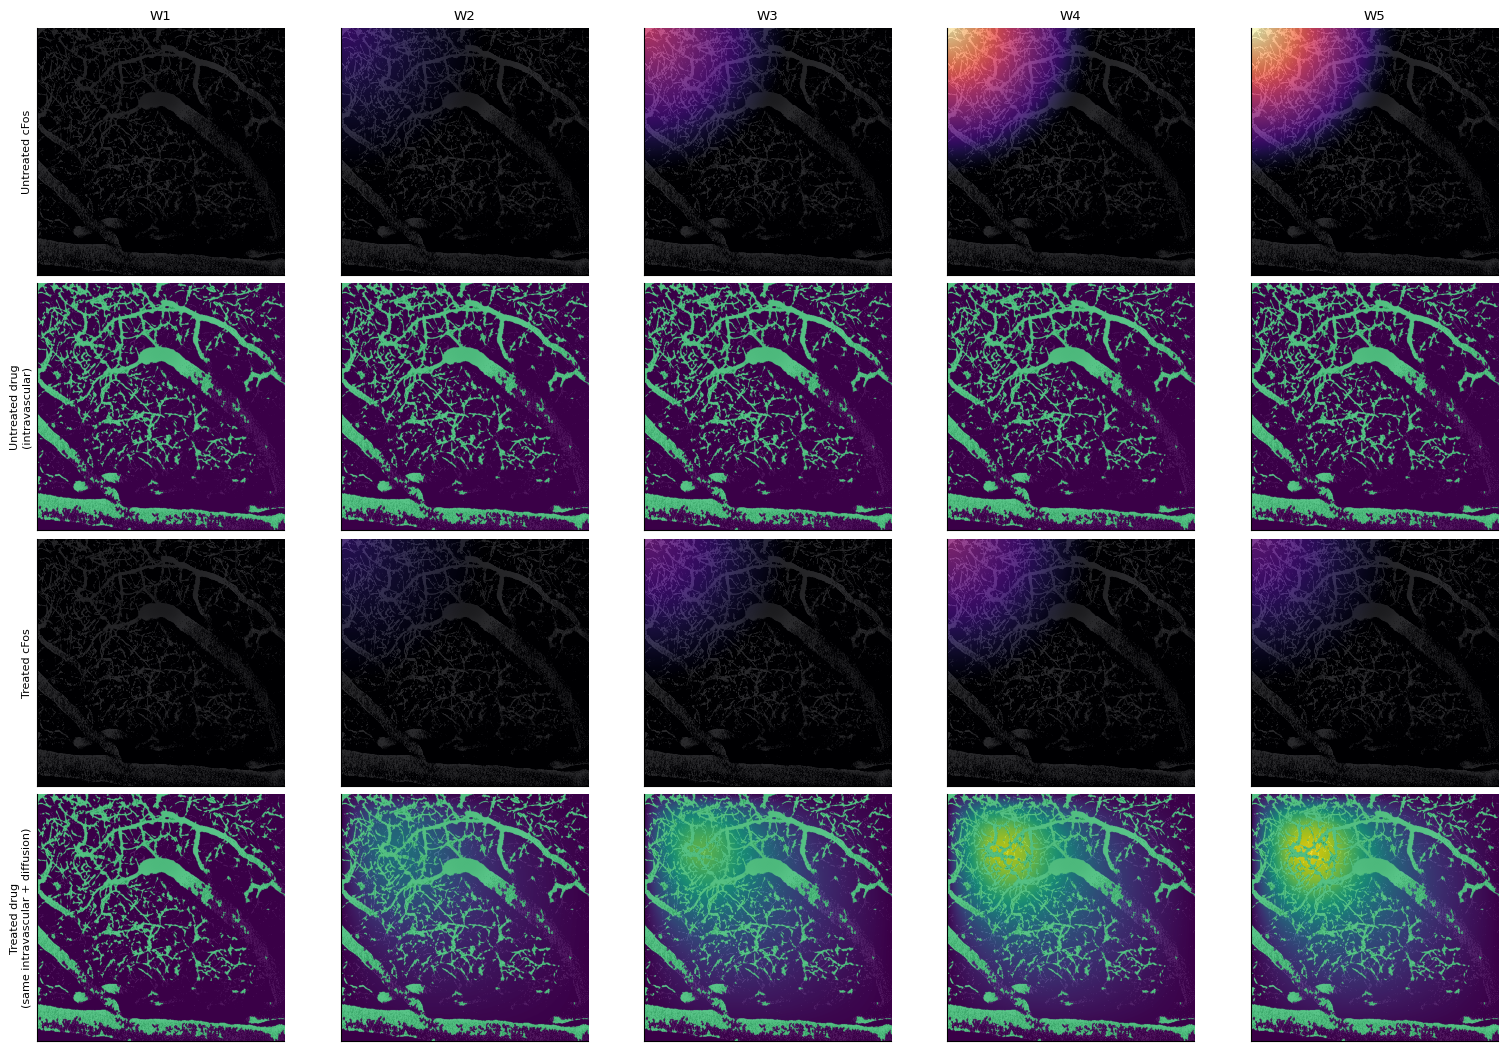

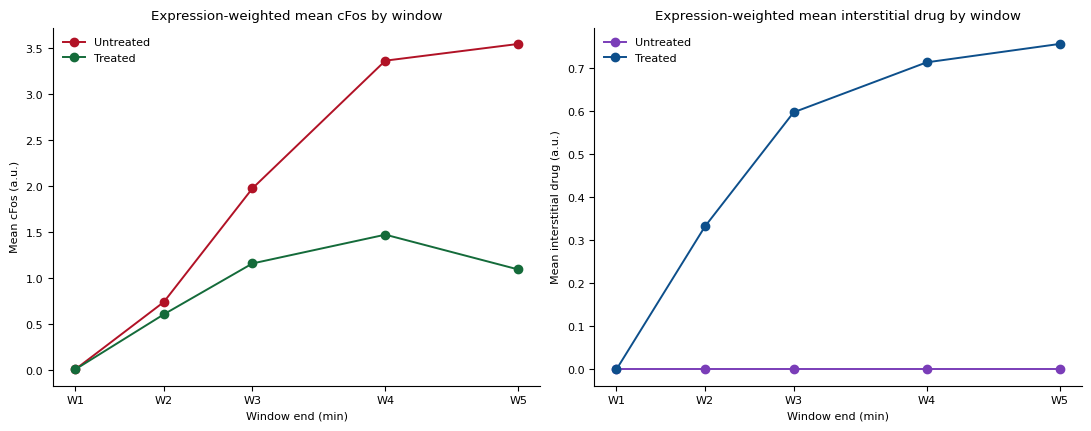

Expression-weighted spatial means:
  cFos untreated: [0.00912 , 0.740984, 1.974559, 3.360822, 3.542379]
  cFos treated  : [0.00912 , 0.607161, 1.159544, 1.472158, 1.094388]
  cFos delta    : [0.      , 0.133823, 0.815014, 1.888664, 2.447992]
  Drug untreated: [0., 0., 0., 0., 0.]
  Drug treated  : [0.      , 0.332553, 0.597655, 0.713693, 0.756502]
  Drug delta    : [0.      , 0.332553, 0.597655, 0.713693, 0.756502]
Spatial spread windows simulated for untreated and treated arms.
Window times (min): [10.0, 20.0, 30.0, 45.0, 60.0]
Suppression amp gain: 0.10
Coupling: opening_gain=1.10, source_gain=3.80, interstitial_gain=12.00, open_rise=0.65, open_decay=0.15
BBB opening target peak by window (from current cFos): [0.9999999997959182, 0.9021845628901204, 0.6483191337737824, 0.48443401001762565, 0.3419062566718625]
BBB opening state peak by window (carried forward): [0.6499999998673469, 1.0, 1.0, 1.0, 1.0]
Interstitial drug peak by window (pre-amplification): [0.0, 0.05306275291317207, 0.0

In [5]:
# Cell 5: spatial cFos spread over five windows (explicit lagged cFos->BBB->drug->cFos coupling)
from scipy.sparse import csr_matrix, lil_matrix
from scipy.sparse.linalg import spsolve

PANEL_A_DATA = Path('panel_a_data.npz')
if not PANEL_A_DATA.exists():
    raise FileNotFoundError('panel_a_data.npz not found. Run Notebook A export cell first.')

with np.load(PANEL_A_DATA) as d:
    vm_spatial = d['vessel_mask'].astype(bool)
    mip_spatial = d['mip'].astype(float)
    expr_spatial = d['expression_map'].astype(float)
    P_spatial = d['P_map'].astype(float)
    bbo_spatial = d['bbo_mask'].astype(bool) if 'bbo_mask' in d else None
    domain_mm_spatial = float(d['domain_mm'])
    dx_mm_spatial = float(d['dx_mm'])

if bbo_spatial is None:
    bbo_spatial = P_spatial > np.min(P_spatial)

extent_spatial = [0.0, domain_mm_spatial, 0.0, domain_mm_spatial]
vm_float = vm_spatial.astype(float)

# Base seed map for spreading dynamics.
seed = np.clip(expr_spatial.astype(float), 0.0, None)
seed = seed / (np.max(seed) + 1e-12)

# Permeability-normalized opening susceptibility map.
P_norm = (P_spatial - np.min(P_spatial)) / (np.max(P_spatial) - np.min(P_spatial) + 1e-12)

# Window endpoints align with your five windows.
window_times = np.array([10.0, 20.0, 30.0, 45.0, 60.0], dtype=float)
window_labels = ['W1', 'W2', 'W3', 'W4', 'W5']

A_u_w = np.interp(window_times, T_EVAL, A_u)
A_t_w = np.interp(window_times, T_EVAL, A_t)
C_t_w = np.interp(window_times, T_EVAL, C_t)

# Spatial spread knobs and coupling gains.
sigma0_px = 2.0
spread_rate_px = 2.5
supp_sigma_gain = 0.0
supp_amp_gain = 0.1
opening_gain = 1.10
source_gain = 3.80
interstitial_gain = 12.0

# BBB opening state dynamics (per-window discrete update).
open_rise = 0.65
open_decay = 0.15


def _solve_steady_spatial(source_map, dx_mm=0.001, D=3e-4, k_loss=0.05):
    ny, nx = source_map.shape
    n = ny * nx
    dx_cm = dx_mm * 0.1

    A_mat = lil_matrix((n, n))
    rhs = np.zeros(n, dtype=float)

    for j in range(ny):
        for i in range(nx):
            idx = j * nx + i
            lap_sum = 0.0
            for di, dj in ((1, 0), (-1, 0), (0, 1), (0, -1)):
                ni, nj = i + di, j + dj
                c = D / (dx_cm ** 2)
                if 0 <= ni < nx and 0 <= nj < ny:
                    A_mat[idx, nj * nx + ni] = c
                    lap_sum += c
                else:
                    lap_sum += c
            A_mat[idx, idx] = -(lap_sum + k_loss)
            rhs[idx] = -source_map[j, i]

    C = spsolve(csr_matrix(A_mat), rhs).reshape(ny, nx)
    return np.clip(C, 0.0, None)


cfos_u_fields = []
cfos_t_fields = []
source_u_windows = []
source_t_windows = []
drug_t_diff_fields = []
bbb_open_windows = []
bbb_open_target_windows = []

# Opening state is carried between windows, so leakage follows prior cFos-induced opening.
open_state = np.zeros_like(vm_float, dtype=float)

for i in range(len(window_times)):
    sigma_u = sigma0_px + spread_rate_px * i
    spread_u = ndimage.gaussian_filter(seed, sigma=sigma_u)
    spread_u = spread_u / (np.max(spread_u) + 1e-12)

    # Untreated cFos baseline field and corresponding vessel-gated opening source.
    field_u = A_u_w[i] * spread_u
    source_u = field_u * vm_float * P_norm

    # Drug leakage uses prior opening state (lag), so cFos precedes interstitial rise.
    drug_drive = C_t_w[i] / (PARAMS['EC50'] + C_t_w[i] + 1e-12)
    drug_drive = drug_drive ** 1.3
    source_t = source_gain * open_state * drug_drive
    drug_t_local = _solve_steady_spatial(source_t, dx_mm=dx_mm_spatial, D=D_tissue, k_loss=k_e)

    # Local suppression from interstitial drug produces treated cFos for this window.
    hill_local = (drug_t_local ** PARAMS['hill_n']) / (
        PARAMS['EC50'] ** PARAMS['hill_n'] + drug_t_local ** PARAMS['hill_n'] + 1e-12
    )
    local_supp = np.clip(supp_amp_gain * hill_local, 0.0, 0.95)
    field_t = np.maximum(A_t_w[i] * spread_u * (1.0 - local_supp), 0.0)

    # Update opening state for next window from current cFos (emergent, not hand-crafted by time).
    open_target = np.clip(opening_gain * (field_t / (np.max(field_u) + 1e-12)), 0.0, 1.0)
    open_target = open_target * vm_float * P_norm
    open_state = np.clip((1.0 - open_decay) * open_state + open_rise * open_target, 0.0, 1.0)

    cfos_u_fields.append(field_u)
    cfos_t_fields.append(field_t)
    source_u_windows.append(source_u)
    source_t_windows.append(source_t)
    drug_t_diff_fields.append(drug_t_local)
    bbb_open_windows.append(open_state.copy())
    bbb_open_target_windows.append(open_target)

cfos_u_fields = np.stack(cfos_u_fields, axis=0)
cfos_t_fields = np.stack(cfos_t_fields, axis=0)
source_u_windows = np.stack(source_u_windows, axis=0)
source_t_windows = np.stack(source_t_windows, axis=0)
drug_t_diff_fields = np.stack(drug_t_diff_fields, axis=0)
bbb_open_windows = np.stack(bbb_open_windows, axis=0)
bbb_open_target_windows = np.stack(bbb_open_target_windows, axis=0)

# Drug concentration rows:
# Untreated: intravascular-only map (static over windows).
drug_u_fields = np.repeat(vm_float[None, :, :], repeats=len(window_times), axis=0)

# Treated: same intravascular concentration as untreated + amplified coupled interstitial diffusion outside vessels.
drug_t_fields = interstitial_gain * drug_t_diff_fields * (1.0 - vm_float[None, :, :]) + vm_float[None, :, :]

# Maximum-distribution maps for summary comparison.
C_u_max = np.max(drug_u_fields, axis=0)
C_t_max = np.max(drug_t_fields, axis=0)
source_u_max = np.max(source_u_windows, axis=0)
source_t_max = np.max(source_t_windows, axis=0)

# Display normalization
cfos_norm_ref = max(np.max(cfos_u_fields), np.max(cfos_t_fields), 1e-12)
drug_norm_ref = max(np.max(C_u_max), np.max(C_t_max), 1e-12)

u_disp = cfos_u_fields / cfos_norm_ref
t_disp = cfos_t_fields / cfos_norm_ref
u_drug_disp = drug_u_fields / drug_norm_ref
t_drug_disp = drug_t_fields / drug_norm_ref

mip_bg = np.clip(
    (mip_spatial - np.percentile(mip_spatial, 2)) /
    (np.percentile(mip_spatial, 99) - np.percentile(mip_spatial, 2) + 1e-12),
    0.0,
    1.0,
)

# 4-row grid: untreated cFos, untreated drug, treated cFos, treated drug.
fig_spread, axes_spread = plt.subplots(4, 5, figsize=(15.2, 10.4), constrained_layout=True)

for i in range(5):
    ax_u_cfos = axes_spread[0, i]
    ax_u_drug = axes_spread[1, i]
    ax_t_cfos = axes_spread[2, i]
    ax_t_drug = axes_spread[3, i]

    ax_u_cfos.imshow(mip_bg, cmap='gray', origin='lower', extent=extent_spatial, interpolation='none')
    ax_u_cfos.imshow(u_disp[i], cmap='magma', origin='lower', extent=extent_spatial, alpha=0.84, vmin=0, vmax=1)
    ax_u_cfos.set_title(f'{window_labels[i]}')

    ax_u_drug.imshow(mip_bg, cmap='gray', origin='lower', extent=extent_spatial, interpolation='none')
    ax_u_drug.imshow(u_drug_disp[i], cmap='viridis', origin='lower', extent=extent_spatial, alpha=0.86, vmin=0, vmax=1)

    ax_t_cfos.imshow(mip_bg, cmap='gray', origin='lower', extent=extent_spatial, interpolation='none')
    ax_t_cfos.imshow(t_disp[i], cmap='magma', origin='lower', extent=extent_spatial, alpha=0.84, vmin=0, vmax=1)

    ax_t_drug.imshow(mip_bg, cmap='gray', origin='lower', extent=extent_spatial, interpolation='none')
    ax_t_drug.imshow(t_drug_disp[i], cmap='viridis', origin='lower', extent=extent_spatial, alpha=0.86, vmin=0, vmax=1)

    for ax in (ax_u_cfos, ax_u_drug, ax_t_cfos, ax_t_drug):
        ax.set_xticks([])
        ax.set_yticks([])

axes_spread[0, 0].set_ylabel('Untreated cFos')
axes_spread[1, 0].set_ylabel('Untreated drug\n(intravascular)')
axes_spread[2, 0].set_ylabel('Treated cFos')
axes_spread[3, 0].set_ylabel('Treated drug\n(same intravascular + diffusion)')

fig_spread.savefig(OUT_DIR / 'CBG_panel_C_spread_windows.svg', bbox_inches='tight', pad_inches=0.02)
plt.show()

bbb_open_peaks = [float(np.max(bbb_open_windows[k])) for k in range(len(window_times))]
bbb_open_target_peaks = [float(np.max(bbb_open_target_windows[k])) for k in range(len(window_times))]
interstitial_peaks = [float(np.max(drug_t_diff_fields[k])) for k in range(len(window_times))]
# Window-summary line plots use expression-weighted spatial means so localized suppression is not averaged away.
cfos_weights = seed / (np.sum(seed) + 1e-12)
interstitial_weights = seed * (1.0 - vm_float)
interstitial_weights = interstitial_weights / (np.sum(interstitial_weights) + 1e-12)
mean_cfos_u = [float(np.average(cfos_u_fields[i], weights=cfos_weights)) for i in range(len(window_times))]
mean_cfos_t = [float(np.average(cfos_t_fields[i], weights=cfos_weights)) for i in range(len(window_times))]
interstitial_mask = ~vm_spatial
mean_drug_u = [float(np.average(drug_u_fields[i][interstitial_mask], weights=interstitial_weights[interstitial_mask])) if np.any(interstitial_mask) else 0.0 for i in range(len(window_times))]
mean_drug_t = [float(np.average(drug_t_fields[i][interstitial_mask], weights=interstitial_weights[interstitial_mask])) if np.any(interstitial_mask) else 0.0 for i in range(len(window_times))]
fig_mean, axes_mean = plt.subplots(1, 2, figsize=(10.8, 4.2), constrained_layout=True)
axes_mean[0].plot(window_times, mean_cfos_u, marker='o', color='#b11226', label='Untreated')
axes_mean[0].plot(window_times, mean_cfos_t, marker='o', color='#146b3a', label='Treated')
axes_mean[0].set_title('Expression-weighted mean cFos by window')
axes_mean[0].set_xlabel('Window end (min)')
axes_mean[0].set_ylabel('Mean cFos (a.u.)')
axes_mean[0].set_xticks(window_times)
axes_mean[0].set_xticklabels(window_labels)
axes_mean[0].legend(frameon=False)
axes_mean[1].plot(window_times, mean_drug_u, marker='o', color='#7a3db8', label='Untreated')
axes_mean[1].plot(window_times, mean_drug_t, marker='o', color='#0d4f8b', label='Treated')
axes_mean[1].set_title('Expression-weighted mean interstitial drug by window')
axes_mean[1].set_xlabel('Window end (min)')
axes_mean[1].set_ylabel('Mean interstitial drug (a.u.)')
axes_mean[1].set_xticks(window_times)
axes_mean[1].set_xticklabels(window_labels)
axes_mean[1].legend(frameon=False)
fig_mean.savefig(OUT_DIR / 'CBG_panel_C_mean_window_lines.svg', bbox_inches='tight', pad_inches=0.02)
plt.show()

print('Expression-weighted spatial means:')
print('  cFos untreated: ' + np.array2string(np.array(mean_cfos_u), precision=6, separator=', '))
print('  cFos treated  : ' + np.array2string(np.array(mean_cfos_t), precision=6, separator=', '))
print('  cFos delta    : ' + np.array2string(np.array(mean_cfos_u) - np.array(mean_cfos_t), precision=6, separator=', '))
print('  Drug untreated: ' + np.array2string(np.array(mean_drug_u), precision=6, separator=', '))
print('  Drug treated  : ' + np.array2string(np.array(mean_drug_t), precision=6, separator=', '))
print('  Drug delta    : ' + np.array2string(np.array(mean_drug_t) - np.array(mean_drug_u), precision=6, separator=', '))

print('Spatial spread windows simulated for untreated and treated arms.')
print(f'Window times (min): {window_times.tolist()}')
print(f'Suppression amp gain: {supp_amp_gain:.2f}')
print(f'Coupling: opening_gain={opening_gain:.2f}, source_gain={source_gain:.2f}, interstitial_gain={interstitial_gain:.2f}, open_rise={open_rise:.2f}, open_decay={open_decay:.2f}')
print(f'BBB opening target peak by window (from current cFos): {bbb_open_target_peaks}')
print(f'BBB opening state peak by window (carried forward): {bbb_open_peaks}')
print(f'Interstitial drug peak by window (pre-amplification): {interstitial_peaks}')
print(f'Peak untreated cFos scalar: {float(np.max(A_u)):.3f}')
print(f'Peak treated cFos scalar: {float(np.max(A_t)):.3f}')
print(f'Max drug untreated (raw): {float(np.max(C_u_max)):.4f}')
print(f'Max drug treated (raw): {float(np.max(C_t_max)):.4f}')

## Spatial spread across five windows

This section reuses the same vasculature view from Notebook A (`panel_a_data.npz`) and simulates cFos spatial spread over five windows:

1. **Untreated**: steady increase with outward spatial extension.
2. **Treated (BBB opening)**: cFos spread is suppressed using a BBB-opening suppression map derived from the Notebook A BBB-open region.

In [6]:
# Cell 5: QC checks and summary metrics
def window_means(signal):
    means = []
    for w0, w1 in WINDOWS:
        m = (T_EVAL >= w0) & (T_EVAL < w1)
        means.append(float(np.mean(signal[m])))
    return means

wm_u = window_means(A_u)
wm_t = window_means(A_t)

peak_t_idx = int(np.argmax(A_t))
peak_t_time = float(T_EVAL[peak_t_idx])
peak_t_val = float(A_t[peak_t_idx])

checks = {
    'untreated_rises_then_plateaus': (wm_u[0] < wm_u[1] < wm_u[2]) and (wm_u[3] <= wm_u[4] * 1.12),
    'treated_has_early_blip': peak_t_time < 30.0,
    'treated_sustained_suppression_late': (wm_t[3] < wm_u[3]) and (wm_t[4] < wm_u[4]) and (wm_t[4] < wm_t[2]),
    'nonnegative_states': bool(np.all(A_u >= -1e-9) and np.all(A_t >= -1e-9) and np.all(C_t >= -1e-9)),
}

print('QC checks:')
for k, v in checks.items():
    print(f'  {k}: {v}')

print('')
print('Key metrics:')
print(f'  Peak cFos treated: {peak_t_val:.3f} at {peak_t_time:.2f} min')
print(f'  Final untreated cFos: {A_u[-1]:.3f}')
print(f'  Final treated cFos: {A_t[-1]:.3f}')
print(f'  Final suppression efficacy: {100 * efficacy[-1]:.2f}%')

QC checks:
  untreated_rises_then_plateaus: True
  treated_has_early_blip: False
  treated_sustained_suppression_late: False
  nonnegative_states: True

Key metrics:
  Peak cFos treated: 2.852 at 45.30 min
  Final untreated cFos: 6.762
  Final treated cFos: 2.102
  Final suppression efficacy: 68.92%


In [7]:
# Cell 7: export data and provenance
import datetime as dt

has_spatial = all(
    name in globals()
    for name in [
        'vm_spatial', 'expr_spatial', 'bbo_spatial',
        'cfos_u_fields', 'cfos_t_fields',
        'source_u_max', 'source_t_max',
        'C_u_max', 'C_t_max', 'window_times',
        'drug_u_fields', 'drug_t_fields',
        'supp_sigma_gain', 'supp_amp_gain'
    ]
)

np.savez(
    OUT_DIR / 'CBG_panel_C_data.npz',
    t=T_EVAL,
    windows=np.array(WINDOWS, dtype=float),
    A_untreated=A_u,
    S_untreated=S_u,
    C_untreated=C_u,
    A_treated=A_t,
    S_treated=S_t,
    C_treated=C_t,
    efficacy=efficacy,
    A_blip=(A_b if sol_blip is not None else np.array([])),
    S_blip=(S_b if sol_blip is not None else np.array([])),
    C_blip=(C_b if sol_blip is not None else np.array([])),
    vm_spatial=(vm_spatial.astype(np.uint8) if has_spatial else np.array([])),
    expr_spatial=(expr_spatial if has_spatial else np.array([])),
    bbo_spatial=(bbo_spatial.astype(np.uint8) if has_spatial else np.array([])),
    window_times=(window_times if has_spatial else np.array([])),
    cfos_u_fields=(cfos_u_fields if has_spatial else np.array([])),
    cfos_t_fields=(cfos_t_fields if has_spatial else np.array([])),
    drug_u_fields=(drug_u_fields if has_spatial else np.array([])),
    drug_t_fields=(drug_t_fields if has_spatial else np.array([])),
    source_u_max=(source_u_max if has_spatial else np.array([])),
    source_t_max=(source_t_max if has_spatial else np.array([])),
    C_u_max=(C_u_max if has_spatial else np.array([])),
    C_t_max=(C_t_max if has_spatial else np.array([])),
)

provenance = {
    'generated': dt.datetime.now().isoformat(),
    'notebook': 'CBG_panel_C_dev.ipynb',
    'objective': 'Untreated vs treated cFos time-course with 5-window spatial spread and BBB-opening suppression',
    'windows_min': WINDOWS,
    'scenarios': {
        'untreated': 'Seizure-driven cFos progression without drug',
        'treated': 'Drug-enabled cFos suppression after onset',
        'blip_arm_included': bool(INCLUDE_BLIP_ARM),
        'blip_duration_min': float(BLIP_DURATION_MIN) if INCLUDE_BLIP_ARM else None,
    },
    'parameters': PARAMS,
    'checks': checks,
    'results': {
        'peak_treated_time_min': peak_t_time,
        'peak_treated_value': peak_t_val,
        'final_untreated': float(A_u[-1]),
        'final_treated': float(A_t[-1]),
        'final_efficacy_percent': float(100 * efficacy[-1]),
    },
    'spatial': {
        'enabled': bool(has_spatial),
        'panel_a_source': 'panel_a_data.npz',
        'window_times_min': window_times.tolist() if has_spatial else None,
        'spatial_shape': list(vm_spatial.shape) if has_spatial else None,
        'dx_mm': float(dx_mm_spatial) if has_spatial else None,
        'domain_mm': float(domain_mm_spatial) if has_spatial else None,
        'suppression_sigma_gain': float(supp_sigma_gain) if has_spatial else None,
        'suppression_amp_gain': float(supp_amp_gain) if has_spatial else None,
        'max_drug_untreated': float(np.max(C_u_max)) if has_spatial else None,
        'max_drug_treated': float(np.max(C_t_max)) if has_spatial else None,
    },
    'fixed_reference_params': {
        'D_tissue_cm2_min': float(D_tissue),
        'P_intact_cm_min': float(P_intact),
        'P_open_cm_min': float(P_open),
        'k_e_per_min': float(k_e),
    },
}

with open(OUT_DIR / 'CBG_panel_C_provenance.json', 'w') as f:
    json.dump(provenance, f, indent=2)

print('Saved outputs to:')
print('  ' + str(OUT_DIR / 'CBG_panel_C_data.npz'))
print('  ' + str(OUT_DIR / 'CBG_panel_C_provenance.json'))
print('  ' + str(OUT_DIR / 'CBG_panel_C_debug.svg'))
if has_spatial:
    print('  ' + str(OUT_DIR / 'CBG_panel_C_spread_windows.svg'))
    print('  ' + str(OUT_DIR / 'CBG_panel_C_spatial_maxdiff_compare.svg'))

Saved outputs to:
  CBG_panel_C_outputs/CBG_panel_C_data.npz
  CBG_panel_C_outputs/CBG_panel_C_provenance.json
  CBG_panel_C_outputs/CBG_panel_C_debug.svg
  CBG_panel_C_outputs/CBG_panel_C_spread_windows.svg
  CBG_panel_C_outputs/CBG_panel_C_spatial_maxdiff_compare.svg
